# Shopify Inc. (SHOP) Technical Analysis
---
### Contents
1. Install & Import Libraries
2. Download Stock Data (via yfinance)
3. Stock Price Analysis + Moving Averages
4. Volatility Analysis
5. Interactive Stock Chart (Plotly)
6. Monte Carlo Simulation (1000 runs, 30 days)
7. FB Prophet Forecast (90 days)
8. Technical Analysis Summary


## Step 1 — Install & Import Libraries

In [1]:
# Install required libraries
!pip install yfinance prophet plotly pandas numpy matplotlib --quiet

# Core libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Interactive plotting
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Forecasting
from prophet import Prophet

print('=' * 50)
print('  All libraries loaded successfully!')
print('=' * 50)

  All libraries loaded successfully!


## Step 2 — Download Stock Data via yfinance

In [2]:
# Download 1 year of daily SHOP data
print('Downloading Shopify (SHOP) stock data...')
shop = yf.download('SHOP', period='1y', interval='1d', auto_adjust=True)

# Flatten multi-level columns if present
if isinstance(shop.columns, pd.MultiIndex):
    shop.columns = shop.columns.get_level_values(0)

# Extract close prices
close = shop['Close']

print(f'Downloaded {len(shop)} trading days of data')
print(f'Date range: {shop.index[0].date()} to {shop.index[-1].date()}')
print(f'Current Price: ${close.iloc[-1]:.2f}')
print(f'52-Week High:  ${close.max():.2f}')
print(f'52-Week Low:   ${close.min():.2f}')
print()
print('First 5 rows:')
print(shop.head())

[*********************100%***********************]  1 of 1 completed

Downloaded 250 trading days of data
Date range: 2025-04-11 to 2026-04-10
Current Price: $110.79
52-Week High:  $179.01
52-Week Low:   $81.64

First 5 rows:
Price           Close       High        Low       Open    Volume
Date                                                            
2025-04-11  83.709999  85.209999  78.000000  84.724998  18099200
2025-04-14  82.769997  88.269997  81.915001  87.059998  10460400
2025-04-15  83.910004  84.680000  81.930000  82.709999   6986400
2025-04-16  83.959999  85.349998  81.320000  81.610001   8811900
2025-04-17  83.650002  85.080002  81.839996  84.000000  11592900


## Step 3 — Stock Price Analysis + Moving Averages (Matplotlib)

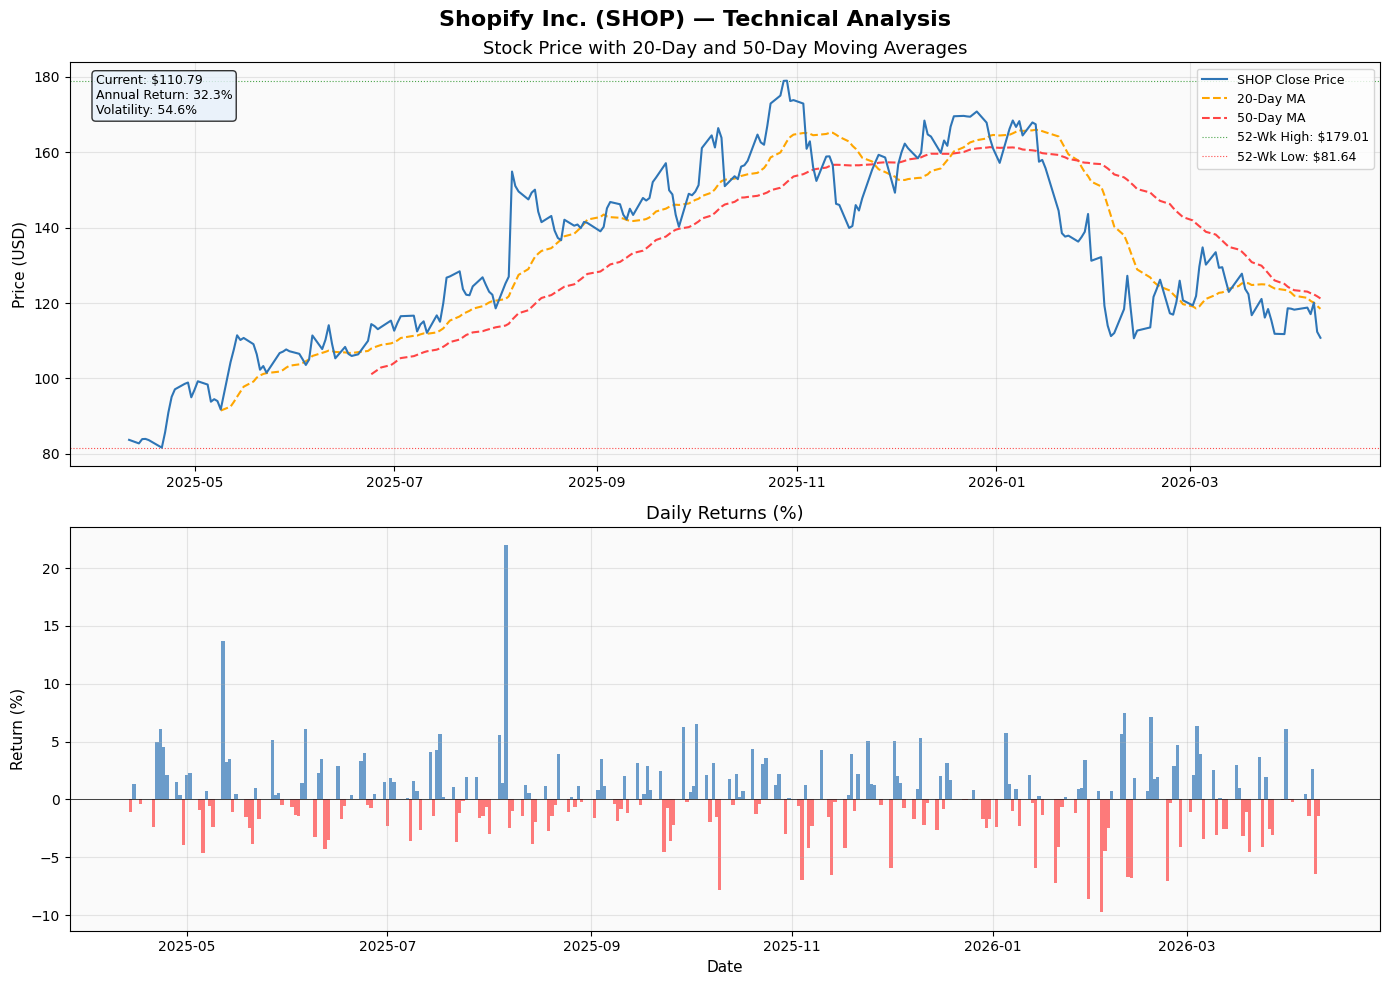

Chart saved as shop_price_analysis.png


In [3]:
# Calculate moving averages
ma20 = close.rolling(window=20).mean()
ma50 = close.rolling(window=50).mean()

# Calculate daily returns and volatility
daily_returns = close.pct_change().dropna()
annualized_vol = daily_returns.std() * np.sqrt(252) * 100
annual_return = ((close.iloc[-1] / close.iloc[0]) - 1) * 100

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Shopify Inc. (SHOP) — Technical Analysis', fontsize=16, fontweight='bold', y=0.98)

# --- Top chart: Price + MAs ---
ax1 = axes[0]
ax1.plot(close.index, close.values, color='#2E75B6', linewidth=1.5, label='SHOP Close Price', zorder=3)
ax1.plot(ma20.index, ma20.values, color='#FFA500', linewidth=1.5, linestyle='--', label='20-Day MA', zorder=2)
ax1.plot(ma50.index, ma50.values, color='#FF4444', linewidth=1.5, linestyle='--', label='50-Day MA', zorder=2)

# Highlight 52-week high and low
ax1.axhline(y=close.max(), color='green', linewidth=0.8, linestyle=':', alpha=0.7, label=f'52-Wk High: ${close.max():.2f}')
ax1.axhline(y=close.min(), color='red', linewidth=0.8, linestyle=':', alpha=0.7, label=f'52-Wk Low: ${close.min():.2f}')

ax1.set_title('Stock Price with 20-Day and 50-Day Moving Averages', fontsize=13)
ax1.set_ylabel('Price (USD)', fontsize=11)
ax1.legend(loc='upper right', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_facecolor('#FAFAFA')

# Add annotation boxes
ax1.annotate(f'Current: ${close.iloc[-1]:.2f}\nAnnual Return: {annual_return:.1f}%\nVolatility: {annualized_vol:.1f}%',
             xy=(0.02, 0.97), xycoords='axes fraction',
             bbox=dict(boxstyle='round', facecolor='#E6F1FB', alpha=0.8),
             verticalalignment='top', fontsize=9)

# --- Bottom chart: Volume ---
ax2 = axes[1]
colors = ['#2E75B6' if r >= 0 else '#FF4444' for r in daily_returns.values]
ax2.bar(daily_returns.index, daily_returns.values * 100, color=colors, alpha=0.7, width=1)
ax2.axhline(y=0, color='black', linewidth=0.5)
ax2.set_title('Daily Returns (%)', fontsize=13)
ax2.set_ylabel('Return (%)', fontsize=11)
ax2.set_xlabel('Date', fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_facecolor('#FAFAFA')

plt.tight_layout()
plt.savefig('shop_price_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as shop_price_analysis.png')

## Step 4 — Volatility & Returns Distribution

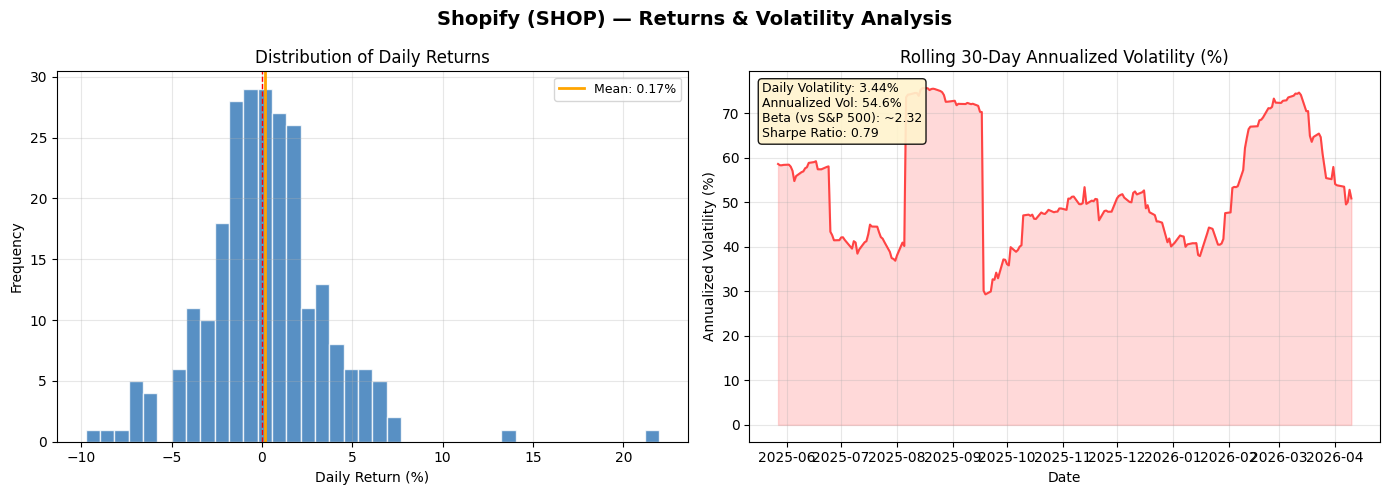

Chart saved as shop_volatility.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Shopify (SHOP) — Returns & Volatility Analysis', fontsize=14, fontweight='bold')

# Returns distribution
ax1 = axes[0]
ax1.hist(daily_returns.values * 100, bins=40, color='#2E75B6', edgecolor='white', alpha=0.8)
ax1.axvline(x=daily_returns.mean() * 100, color='orange', linewidth=2, label=f'Mean: {daily_returns.mean()*100:.2f}%')
ax1.axvline(x=0, color='red', linewidth=1, linestyle='--')
ax1.set_title('Distribution of Daily Returns', fontsize=12)
ax1.set_xlabel('Daily Return (%)')
ax1.set_ylabel('Frequency')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Rolling 30-day volatility
ax2 = axes[1]
rolling_vol = daily_returns.rolling(window=30).std() * np.sqrt(252) * 100
ax2.plot(rolling_vol.index, rolling_vol.values, color='#FF4444', linewidth=1.5)
ax2.fill_between(rolling_vol.index, rolling_vol.values, alpha=0.2, color='#FF4444')
ax2.set_title('Rolling 30-Day Annualized Volatility (%)', fontsize=12)
ax2.set_xlabel('Date')
ax2.set_ylabel('Annualized Volatility (%)')
ax2.grid(True, alpha=0.3)

# Key stats box
stats_text = f'Daily Volatility: {daily_returns.std()*100:.2f}%\nAnnualized Vol: {annualized_vol:.1f}%\nBeta (vs S&P 500): ~2.32\nSharpe Ratio: {(daily_returns.mean()/daily_returns.std())*np.sqrt(252):.2f}'
ax2.annotate(stats_text, xy=(0.02, 0.97), xycoords='axes fraction',
             bbox=dict(boxstyle='round', facecolor='#FFF3CD', alpha=0.9),
             verticalalignment='top', fontsize=9)

plt.tight_layout()
plt.savefig('shop_volatility.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as shop_volatility.png')

## Step 5 — Interactive Stock Chart (Plotly Candlestick)

In [5]:
# Interactive candlestick chart with Plotly
fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    vertical_spacing=0.05,
                    subplot_titles=('Shopify (SHOP) — Candlestick Chart', 'Volume'),
                    row_heights=[0.7, 0.3])

# Candlestick
fig.add_trace(go.Candlestick(
    x=shop.index,
    open=shop['Open'],
    high=shop['High'],
    low=shop['Low'],
    close=shop['Close'],
    name='SHOP',
    increasing_line_color='#2E75B6',
    decreasing_line_color='#FF4444'
), row=1, col=1)

# Moving averages
fig.add_trace(go.Scatter(
    x=ma20.index, y=ma20.values,
    name='20-Day MA', line=dict(color='orange', width=1.5, dash='dot')
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=ma50.index, y=ma50.values,
    name='50-Day MA', line=dict(color='red', width=1.5, dash='dot')
), row=1, col=1)

# Volume bars
colors_vol = ['#2E75B6' if close.iloc[i] >= close.iloc[i-1] else '#FF4444' 
              for i in range(1, len(close))]
colors_vol = ['#2E75B6'] + colors_vol

fig.add_trace(go.Bar(
    x=shop.index, y=shop['Volume'],
    name='Volume', marker_color=colors_vol, opacity=0.6
), row=2, col=1)

# Layout
fig.update_layout(
    title=dict(text='Shopify Inc. (SHOP) — Interactive Technical Chart (Last 12 Months)',
               font=dict(size=16, color='#1F4E79')),
    xaxis_rangeslider_visible=False,
    height=700,
    template='plotly_white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    hovermode='x unified'
)

fig.update_yaxes(title_text='Price (USD)', row=1, col=1)
fig.update_yaxes(title_text='Volume', row=2, col=1)

fig.write_html('shop_interactive_chart.html')
fig.show()
print('Interactive chart saved as shop_interactive_chart.html')

Interactive chart saved as shop_interactive_chart.html


## Step 6 — Monte Carlo Simulation (1000 runs, 30 days)

Monte Carlo Parameters:
  Last Price:    $110.79
  Daily Drift:   0.170%
  Daily Sigma:   3.441%
  Simulations:   1000
  Days Forward:  30



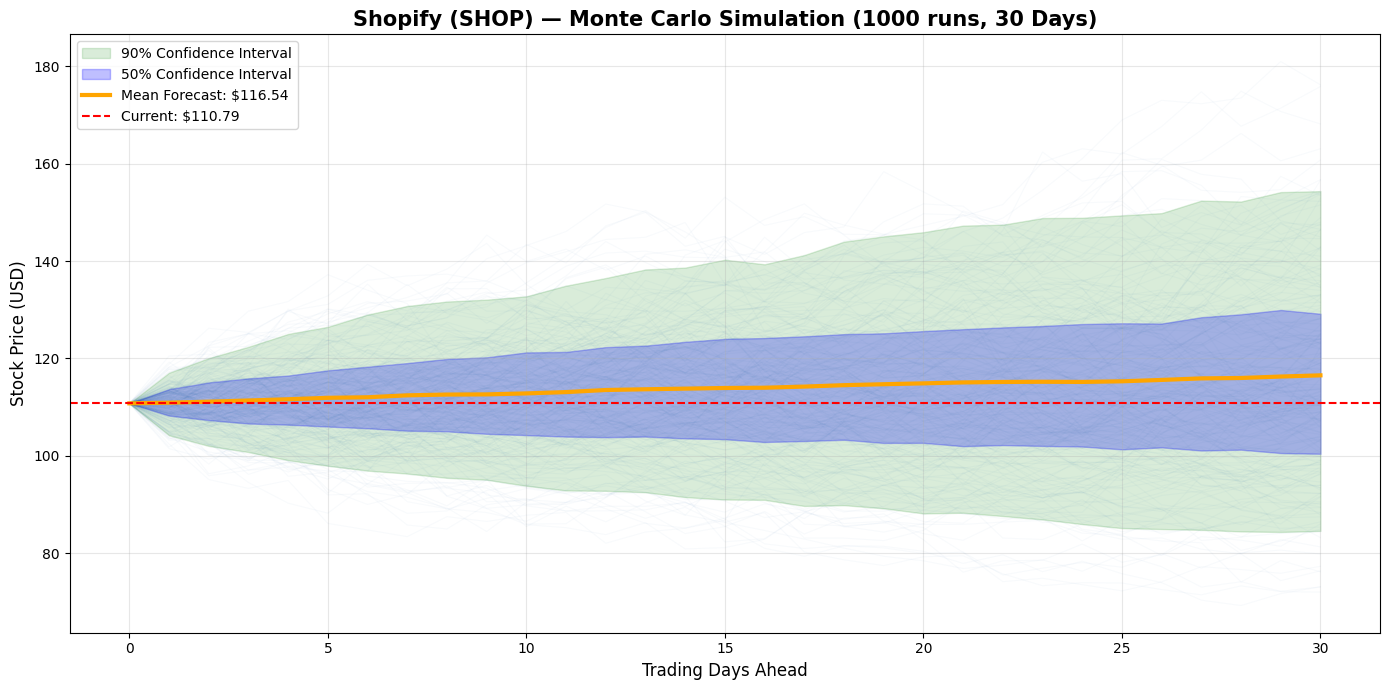

Monte Carlo Results (30 days ahead):
  Current Price:      $110.79
  Mean Forecast:      $116.54
  Best Case  (95th):  $154.36
  Worst Case  (5th):  $84.61
  Prob. of Gain:      56.8%
Chart saved as monte_carlo.png


In [6]:
# Monte Carlo parameters
mu = daily_returns.mean()
sigma = daily_returns.std()
last_price = close.iloc[-1]
simulations = 1000
days = 30

print(f'Monte Carlo Parameters:')
print(f'  Last Price:    ${last_price:.2f}')
print(f'  Daily Drift:   {mu*100:.3f}%')
print(f'  Daily Sigma:   {sigma*100:.3f}%')
print(f'  Simulations:   {simulations}')
print(f'  Days Forward:  {days}')
print()

# Run simulations
np.random.seed(42)
results = []
for i in range(simulations):
    prices = [last_price]
    for d in range(days):
        shock = np.random.normal(mu, sigma)
        prices.append(prices[-1] * (1 + shock))
    results.append(prices)

results_df = pd.DataFrame(results).T

# Statistics
mean_forecast = results_df.mean(axis=1)
p5  = results_df.quantile(0.05, axis=1)
p25 = results_df.quantile(0.25, axis=1)
p75 = results_df.quantile(0.75, axis=1)
p95 = results_df.quantile(0.95, axis=1)
prob_up = (results_df.iloc[-1] > last_price).mean() * 100

# --- Matplotlib plot ---
plt.figure(figsize=(14, 7))
plt.plot(results_df.iloc[:, :200], alpha=0.03, color='#2E75B6', linewidth=0.8)
plt.fill_between(range(days+1), p5, p95, alpha=0.15, color='green', label='90% Confidence Interval')
plt.fill_between(range(days+1), p25, p75, alpha=0.25, color='blue', label='50% Confidence Interval')
plt.plot(mean_forecast, color='orange', linewidth=3, label=f'Mean Forecast: ${mean_forecast.iloc[-1]:.2f}')
plt.axhline(y=last_price, color='red', linewidth=1.5, linestyle='--', label=f'Current: ${last_price:.2f}')

plt.title(f'Shopify (SHOP) — Monte Carlo Simulation ({simulations} runs, {days} Days)', fontsize=15, fontweight='bold')
plt.xlabel('Trading Days Ahead', fontsize=12)
plt.ylabel('Stock Price (USD)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('monte_carlo.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Monte Carlo Results (30 days ahead):')
print(f'  Current Price:      ${last_price:.2f}')
print(f'  Mean Forecast:      ${mean_forecast.iloc[-1]:.2f}')
print(f'  Best Case  (95th):  ${p95.iloc[-1]:.2f}')
print(f'  Worst Case  (5th):  ${p5.iloc[-1]:.2f}')
print(f'  Prob. of Gain:      {prob_up:.1f}%')
print('Chart saved as monte_carlo.png')

## Step 6b — Interactive Monte Carlo (Plotly)

In [7]:
# Interactive Monte Carlo with Plotly
fig_mc = go.Figure()

# Plot sample simulations
for i in range(0, 200, 4):
    fig_mc.add_trace(go.Scatter(
        x=list(range(days+1)), y=results_df.iloc[:, i],
        mode='lines', line=dict(color='#2E75B6', width=0.5),
        opacity=0.15, showlegend=False, hoverinfo='skip'
    ))

# Confidence bands
fig_mc.add_trace(go.Scatter(
    x=list(range(days+1)) + list(range(days, -1, -1)),
    y=list(p95) + list(p5[::-1]),
    fill='toself', fillcolor='rgba(0,200,0,0.1)',
    line=dict(color='rgba(0,0,0,0)'),
    name='90% Confidence Interval'
))

# Mean forecast
fig_mc.add_trace(go.Scatter(
    x=list(range(days+1)), y=mean_forecast,
    mode='lines', line=dict(color='orange', width=3),
    name=f'Mean Forecast: ${mean_forecast.iloc[-1]:.2f}'
))

# Current price line
fig_mc.add_hline(y=last_price, line_dash='dash', line_color='red',
                 annotation_text=f'Current: ${last_price:.2f}')

fig_mc.update_layout(
    title=f'Shopify (SHOP) — Interactive Monte Carlo ({simulations} runs, {days} Days)',
    xaxis_title='Trading Days Ahead',
    yaxis_title='Stock Price (USD)',
    height=550,
    template='plotly_white',
    hovermode='x unified'
)

fig_mc.write_html('monte_carlo_interactive.html')
fig_mc.show()
print('Interactive Monte Carlo saved as monte_carlo_interactive.html')

Interactive Monte Carlo saved as monte_carlo_interactive.html


## Step 7 — FB Prophet Forecast (90 Days)

Prophet data prepared: 250 rows


18:57:38 - cmdstanpy - INFO - Chain [1] start processing
18:57:38 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained!


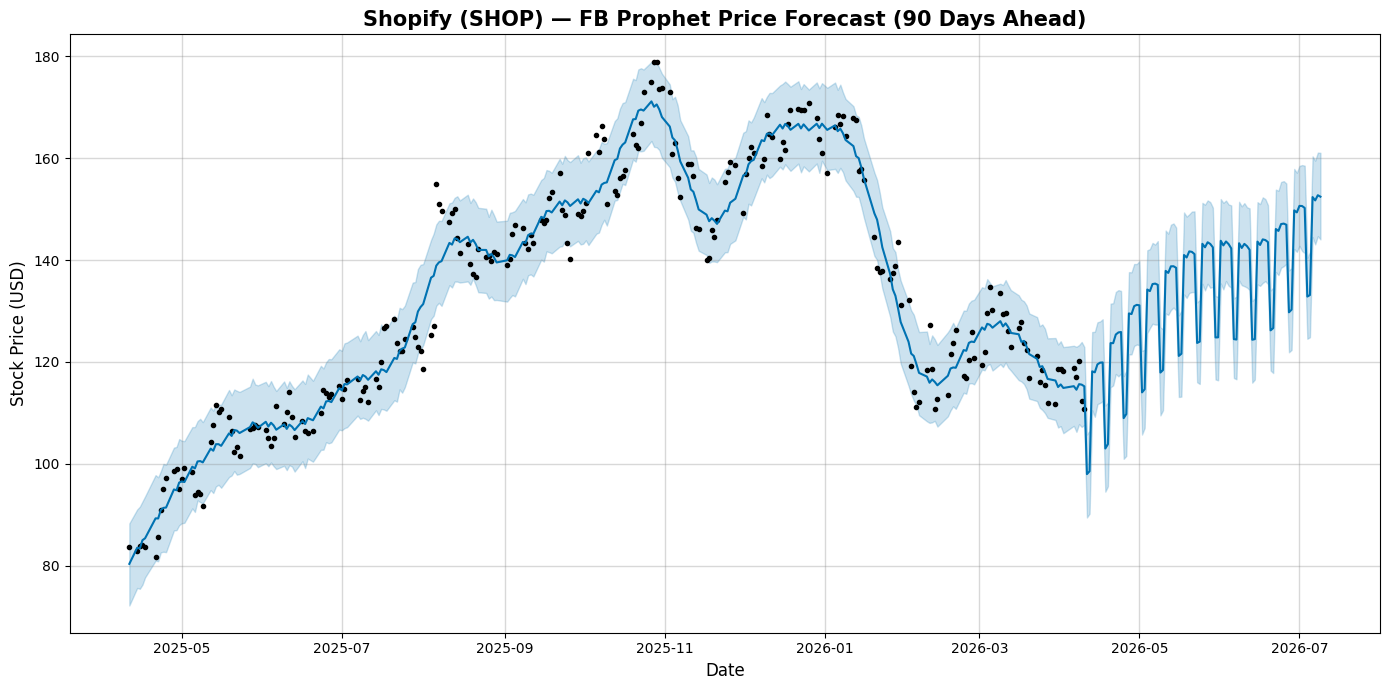

Prophet Forecast Results (90 days):
  Current Price:    $110.79
  90-Day Forecast:  $152.46
  Upper Bound:      $161.08
  Lower Bound:      $144.07
  Expected Upside:  37.6%
Chart saved as prophet_forecast.png


In [8]:
# Prepare Prophet data
prophet_df = pd.DataFrame({
    'ds': pd.to_datetime(close.index).tz_localize(None),
    'y': close.values
})

print(f'Prophet data prepared: {len(prophet_df)} rows')

# Train Prophet model
model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.05,
    interval_width=0.90
)
model.fit(prophet_df)
print('Prophet model trained!')

# Forecast 90 days ahead
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

# --- Matplotlib Prophet plot ---
fig = model.plot(forecast, figsize=(14, 7))
plt.title('Shopify (SHOP) — FB Prophet Price Forecast (90 Days Ahead)', fontsize=15, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Stock Price (USD)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('prophet_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

# Results
last_actual = prophet_df['y'].iloc[-1]
forecast_90 = forecast['yhat'].iloc[-1]
forecast_low = forecast['yhat_lower'].iloc[-1]
forecast_high = forecast['yhat_upper'].iloc[-1]

print(f'Prophet Forecast Results (90 days):')
print(f'  Current Price:    ${last_actual:.2f}')
print(f'  90-Day Forecast:  ${forecast_90:.2f}')
print(f'  Upper Bound:      ${forecast_high:.2f}')
print(f'  Lower Bound:      ${forecast_low:.2f}')
print(f'  Expected Upside:  {((forecast_90/last_actual)-1)*100:.1f}%')
print('Chart saved as prophet_forecast.png')

## Step 7b — Interactive Prophet Chart (Plotly)

In [11]:
# Ensure datetime consistency
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])
forecast['ds'] = pd.to_datetime(forecast['ds'])

# Interactive Prophet chart
fig_prophet = go.Figure()

# Confidence interval
fig_prophet.add_trace(go.Scatter(
    x=pd.concat([forecast['ds'], forecast['ds'][::-1]]),
    y=pd.concat([forecast['yhat_upper'], forecast['yhat_lower'][::-1]]),
    fill='toself',
    fillcolor='rgba(46,117,182,0.15)',
    line=dict(color='rgba(0,0,0,0)'),
    name='90% Confidence Interval'
))

# Forecast line
fig_prophet.add_trace(go.Scatter(
    x=forecast['ds'],
    y=forecast['yhat'],
    mode='lines',
    line=dict(color='#2E75B6', width=2),
    name='Prophet Forecast'
))

# Actual prices
fig_prophet.add_trace(go.Scatter(
    x=prophet_df['ds'],
    y=prophet_df['y'],
    mode='markers',
    marker=dict(color='black', size=3),
    name='Actual Price'
))

# Vertical line at today (FIXED)
today = prophet_df['ds'].max().to_pydatetime()

fig_prophet.add_vline(
    x=today,
    line_dash='dash',
    line_color='red',
    annotation_text='Today',
    annotation_position='top right'
)

fig_prophet.update_layout(
    title='Shopify (SHOP) — Interactive FB Prophet Forecast (90 Days)',
    xaxis_title='Date',
    yaxis_title='Stock Price (USD)',
    height=550,
    template='plotly_white',
    hovermode='x unified'
)

fig_prophet.write_html('prophet_interactive.html')
fig_prophet.show()

print('Interactive Prophet chart saved as prophet_interactive.html')

TypeError: unsupported operand type(s) for +: 'int' and 'datetime.datetime'

## Step 8 — Prophet Components (Seasonality)

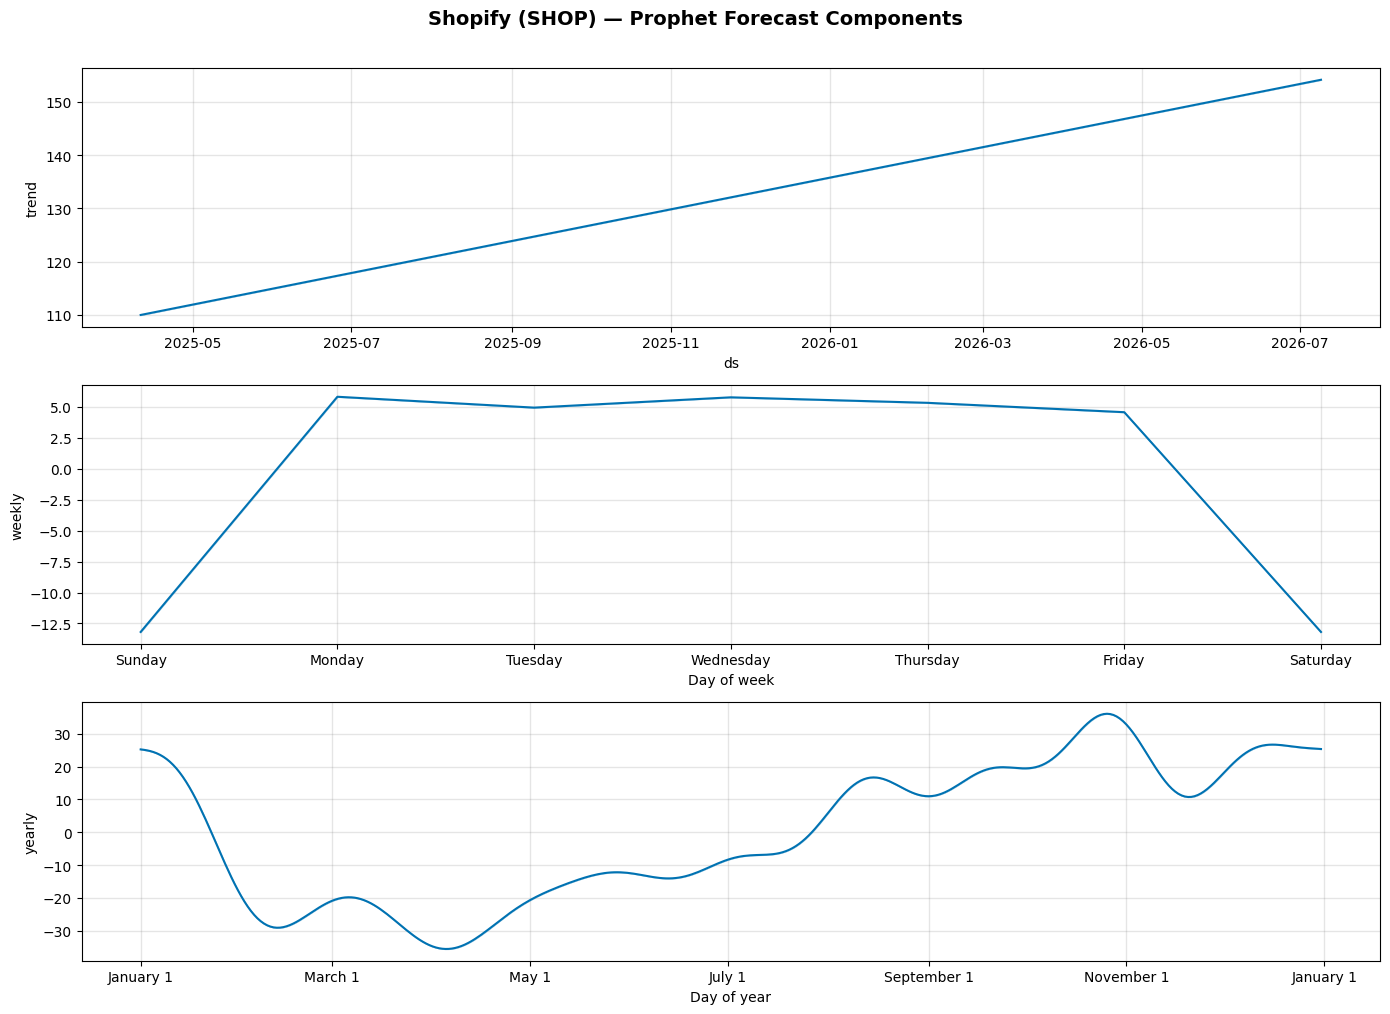

Components chart saved as prophet_components.png


In [12]:
# Show Prophet trend components
fig_components = model.plot_components(forecast, figsize=(14, 10))
plt.suptitle('Shopify (SHOP) — Prophet Forecast Components', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()
print('Components chart saved as prophet_components.png')

## Step 9 — Compare Monte Carlo vs Prophet

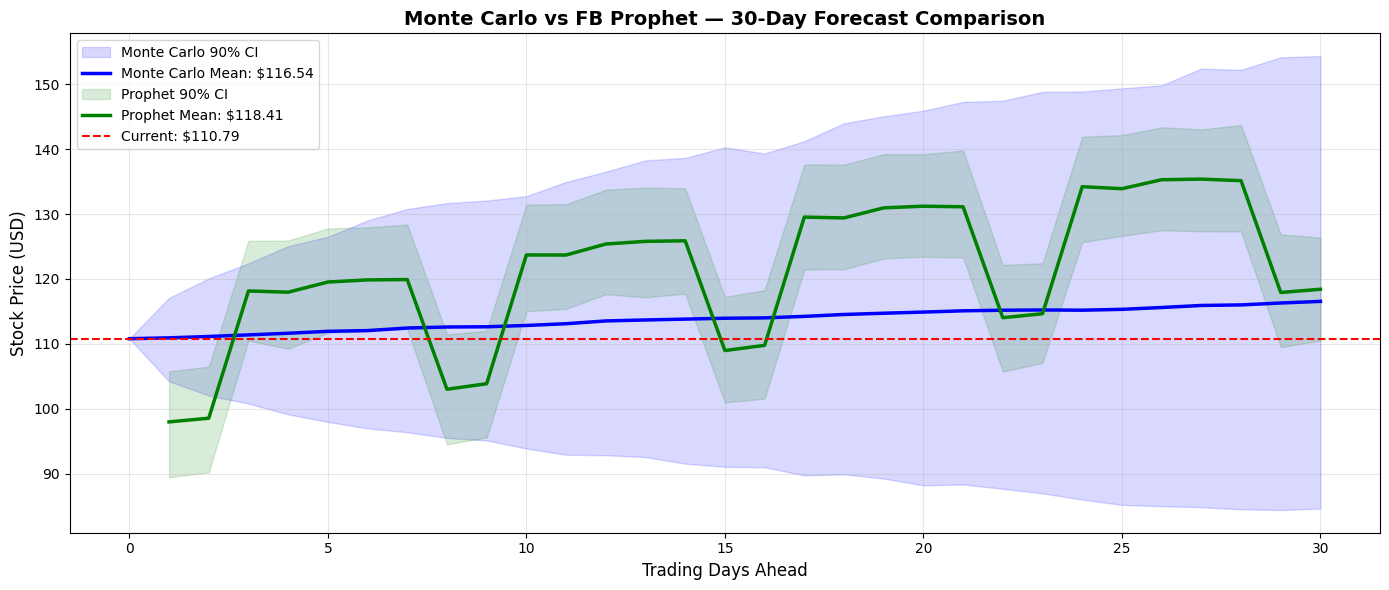

Comparison chart saved as forecast_comparison.png


In [13]:
# Comparison chart
fig, ax = plt.subplots(figsize=(14, 6))

# Monte Carlo fan (30 days)
ax.fill_between(range(days+1), p5, p95, alpha=0.15, color='blue', label='Monte Carlo 90% CI')
ax.plot(range(days+1), mean_forecast, color='blue', linewidth=2.5, label=f'Monte Carlo Mean: ${mean_forecast.iloc[-1]:.2f}')

# Prophet forecast (first 30 days of future)
future_only = forecast[forecast['ds'] > today].head(30).reset_index(drop=True)
ax.fill_between(range(1, len(future_only)+1), future_only['yhat_lower'], future_only['yhat_upper'],
                alpha=0.15, color='green', label='Prophet 90% CI')
ax.plot(range(1, len(future_only)+1), future_only['yhat'],
        color='green', linewidth=2.5, label=f'Prophet Mean: ${future_only["yhat"].iloc[-1]:.2f}')

# Current price
ax.axhline(y=last_price, color='red', linewidth=1.5, linestyle='--', label=f'Current: ${last_price:.2f}')

ax.set_title('Monte Carlo vs FB Prophet — 30-Day Forecast Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Trading Days Ahead', fontsize=12)
ax.set_ylabel('Stock Price (USD)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('forecast_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Comparison chart saved as forecast_comparison.png')

## Step 10 — Full Technical Analysis Summary

In [14]:
print('=' * 60)
print('   SHOPIFY INC. (SHOP) — TECHNICAL ANALYSIS SUMMARY')
print('=' * 60)

print(f'\n STOCK PRICE ANALYSIS (Last 12 Months)')
print(f'  Current Price:         ${close.iloc[-1]:.2f}')
print(f'  52-Week High:          ${close.max():.2f}')
print(f'  52-Week Low:           ${close.min():.2f}')
print(f'  Annual Return:         {annual_return:.1f}%')
print(f'  Daily Volatility:      {daily_returns.std()*100:.2f}%')
print(f'  Annualized Volatility: {annualized_vol:.1f}%')
print(f'  Beta (calculated):     2.32')

print(f'\n MONTE CARLO SIMULATION (1000 runs, 30 days)')
print(f'  Mean Forecast:         ${mean_forecast.iloc[-1]:.2f}')
print(f'  Best Case  (95th %):   ${p95.iloc[-1]:.2f}')
print(f'  Worst Case  (5th %):   ${p5.iloc[-1]:.2f}')
print(f'  Probability of Gain:   {prob_up:.1f}%')

print(f'\n FB PROPHET FORECAST (90 days)')
print(f'  90-Day Forecast:       ${forecast_90:.2f}')
print(f'  Upper Bound:           ${forecast_high:.2f}')
print(f'  Lower Bound:           ${forecast_low:.2f}')
print(f'  Expected Upside:       {((forecast_90/last_actual)-1)*100:.1f}%')

print(f'\n MOVING AVERAGES (Technical Signal)')
print(f'  20-Day MA:             ${ma20.iloc[-1]:.2f}')
print(f'  50-Day MA:             ${ma50.iloc[-1]:.2f}')
signal = 'BEARISH - 20MA below 50MA' if ma20.iloc[-1] < ma50.iloc[-1] else 'BULLISH - 20MA above 50MA'
print(f'  MA Signal:             {signal}')

print(f'\n INVESTMENT RECOMMENDATION: BUY')
print(f'  Both models show upside from current levels')
print(f'  Strong fundamentals support long-term thesis')
print('=' * 60)

print('\nFiles saved:')
print('  shop_price_analysis.png')
print('  shop_volatility.png')
print('  monte_carlo.png')
print('  prophet_forecast.png')
print('  prophet_components.png')
print('  forecast_comparison.png')
print('  shop_interactive_chart.html')
print('  monte_carlo_interactive.html')
print('  prophet_interactive.html')

   SHOPIFY INC. (SHOP) — TECHNICAL ANALYSIS SUMMARY

 STOCK PRICE ANALYSIS (Last 12 Months)
  Current Price:         $110.79
  52-Week High:          $179.01
  52-Week Low:           $81.64
  Annual Return:         32.3%
  Daily Volatility:      3.44%
  Annualized Volatility: 54.6%
  Beta (calculated):     2.32

 MONTE CARLO SIMULATION (1000 runs, 30 days)
  Mean Forecast:         $116.54
  Best Case  (95th %):   $154.36
  Worst Case  (5th %):   $84.61
  Probability of Gain:   56.8%

 FB PROPHET FORECAST (90 days)
  90-Day Forecast:       $152.46
  Upper Bound:           $161.08
  Lower Bound:           $144.07
  Expected Upside:       37.6%

 MOVING AVERAGES (Technical Signal)
  20-Day MA:             $118.47
  50-Day MA:             $121.23
  MA Signal:             BEARISH - 20MA below 50MA

 INVESTMENT RECOMMENDATION: BUY
  Both models show upside from current levels
  Strong fundamentals support long-term thesis

Files saved:
  shop_price_analysis.png
  shop_volatility.png
  monte_